In [2]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('cleaned_transcripts.csv')

print(f"Videos  : {len(df)}")
print(f"Columns : {list(df.columns)}")
print(f"Missing values:\n{df.isnull().sum()}")
df.head()

Videos  : 123
Columns : ['video_id', 'title', 'datetime', 'transcript']
Missing values:
video_id      0
title         0
datetime      0
transcript    0
dtype: int64


,video_id,title,datetime,transcript
0,2KaAHD2TOos,Is dust really people?,2026-02-13,(finger squeaking) - Is dust just people? You ...
1,iT2n41ZFDc0,The Intelligence Test Where Ants Beat Humans,2026-02-05,- Thank you to AnyDesk for supporting PBS. Eve...
2,UI8pp2j2fZ8,What time is it on Voyager 1? 🤔,2026-01-30,- What's the farthest manmade object from Eart...
3,rTvTsvT7y7s,What& 39;s REALLY killing all the birds?,2026-01-23,"- You may have gotten wind, the turbines like ..."
4,AxE13l_rXOI,How much does Will Smith know about nature?,2026-01-18,We recently had the opportunity to play a fun ...


In [6]:
# Load Best Mode

MODEL_NAME = 'all-mpnet-base-v2'

print(f"Loading model: {MODEL_NAME}")
model = SentenceTransformer(MODEL_NAME)
print("Model loaded successfully!")

Loading model: all-mpnet-base-v2


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4089.98it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!


In [7]:
# Generate Title Embeddings

print("Generating title embeddings...")
title_embeddings = model.encode(df['title'].tolist(), show_progress_bar=True)

print(f"Title embeddings shape: {title_embeddings.shape}")

Generating title embeddings...


Batches: 100%|██████████| 4/4 [00:02<00:00,  1.41it/s]

Title embeddings shape: (123, 768)


In [8]:
# Generate Transcript Embeddings

print("Generating transcript embeddings...")
transcript_embeddings = model.encode(df['transcript'].tolist(), show_progress_bar=True)

print(f"Transcript embeddings shape: {transcript_embeddings.shape}")

Generating transcript embeddings...


Batches: 100%|██████████| 4/4 [00:45<00:00, 11.27s/it]

Transcript embeddings shape: (123, 768)


In [9]:
# Combine Title + Transcript

print("Combining title and transcript embeddings (averaging)...")
combined_embeddings = (title_embeddings + transcript_embeddings) / 2

print(f"Combined embeddings shape: {combined_embeddings.shape}")

Combining title and transcript embeddings (averaging)...
Combined embeddings shape: (123, 768)


In [10]:
# Attach Embeddings to Dataset

embedding_df = pd.DataFrame(
    combined_embeddings,
    columns=[f'emb_{i}' for i in range(combined_embeddings.shape[1])]
)

video_index = pd.concat([df[['video_id', 'title', 'datetime', 'transcript']], embedding_df], axis=1)

print(f"Final dataset shape: {video_index.shape}")
video_index.head()

Final dataset shape: (123, 772)


,video_id,title,datetime,transcript,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,...,emb_758,emb_759,emb_760,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767
0,2KaAHD2TOos,Is dust really people?,2026-02-13,(finger squeaking) - Is dust just people? You ...,0.054565,-0.002372,-0.016723,0.023227,-0.001401,-0.019602,...,0.046776,-0.070238,-0.057803,0.002024,-0.000382,0.056404,0.024956,0.006726,0.014306,0.007371
1,iT2n41ZFDc0,The Intelligence Test Where Ants Beat Humans,2026-02-05,- Thank you to AnyDesk for supporting PBS. Eve...,0.008387,0.026293,-0.019807,-0.011747,-0.036581,-0.006772,...,0.011056,0.000688,-0.037942,0.000246,0.010358,0.030810,-0.047398,0.016151,0.017851,-0.023191
2,UI8pp2j2fZ8,What time is it on Voyager 1? 🤔,2026-01-30,- What's the farthest manmade object from Eart...,0.025188,-0.010536,0.024582,-0.018753,-0.073070,0.004792,...,0.003069,-0.019464,0.010874,-0.004011,0.018933,0.063648,-0.034239,-0.002170,-0.058280,-0.006763
3,rTvTsvT7y7s,What& 39;s REALLY killing all the birds?,2026-01-23,"- You may have gotten wind, the turbines like ...",-0.005432,0.079383,-0.004182,0.008851,-0.021373,-0.013760,...,0.039434,-0.026513,-0.013852,-0.041770,0.008235,-0.002218,-0.000635,0.045312,-0.008180,0.008561
4,AxE13l_rXOI,How much does Will Smith know about nature?,2026-01-18,We recently had the opportunity to play a fun ...,0.002758,0.083632,-0.033066,0.004775,-0.027377,-0.013858,...,0.065525,0.002762,-0.016107,-0.076558,0.006466,0.030456,0.007026,0.028984,-0.008471,0.020330


In [11]:
# Save to CSV

video_index.to_csv('video_index.csv', index=False)
print("Saved: video_index.csv")

Saved: video_index.csv


In [12]:
# Verify Integrity

# Load back and verify
loaded = pd.read_csv('video_index.csv')

emb_cols = [col for col in loaded.columns if col.startswith('emb_')]

print(f"Total rows          : {len(loaded)}")
print(f"Embedding dimensions: {len(emb_cols)}")
print(f"Null embeddings     : {loaded[emb_cols].isnull().sum().sum()}")
print(f"All checks passed   : {len(loaded) == len(df) and loaded[emb_cols].isnull().sum().sum() == 0}")

Total rows          : 123
Embedding dimensions: 768
Null embeddings     : 0
All checks passed   : True


Reducing to 2D using PCA...


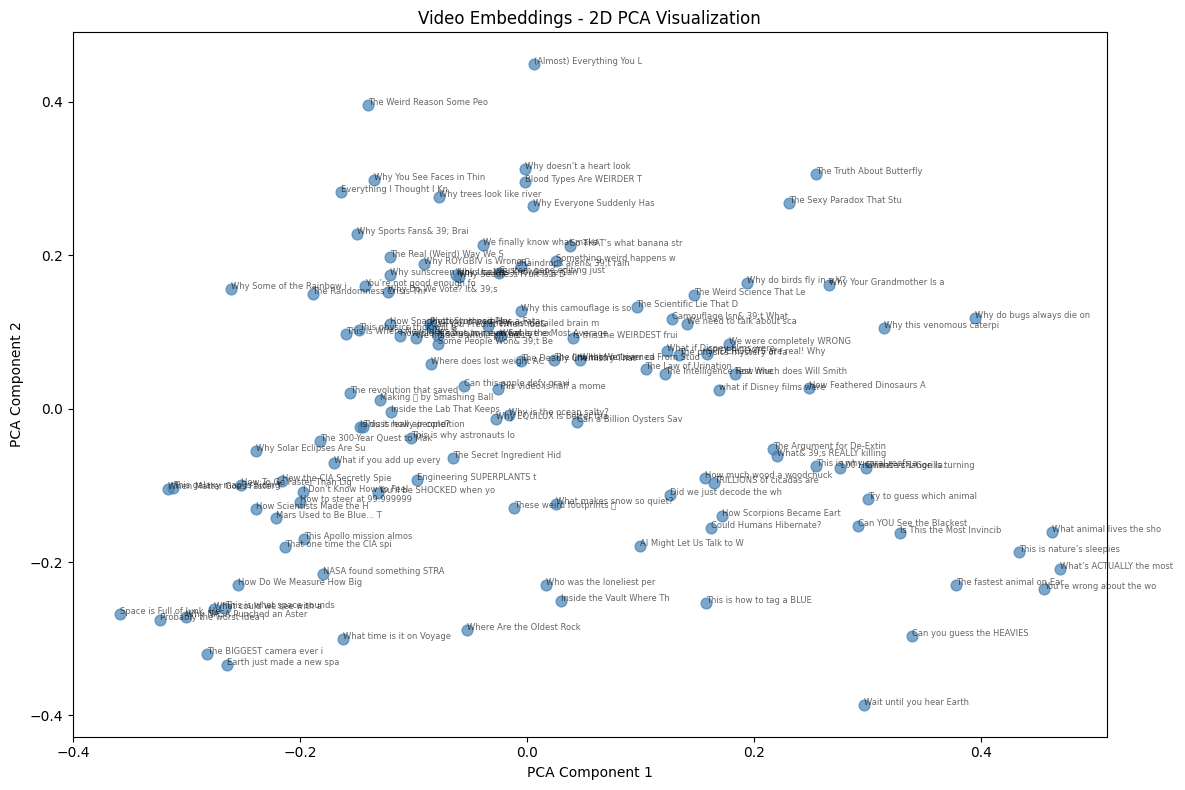

Saved: embedding_visualization.png


In [13]:
# Visualize (Optional)

print("Reducing to 2D using PCA...")
pca = PCA(n_components=2)
reduced = pca.fit_transform(combined_embeddings)

plt.figure(figsize=(12, 8))
plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.7, color='steelblue', s=60)

for i, row in df.iterrows():
    plt.annotate(row['title'][:25], (reduced[i, 0], reduced[i, 1]), fontsize=6, alpha=0.6)

plt.title('Video Embeddings - 2D PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.savefig('embedding_visualization.png', dpi=150)
plt.show()
print("Saved: embedding_visualization.png")